# 1. Análise Analítica de Seção Elíptica 2D (Modos TE e TM)

Este notebook calcula os parâmetros fundamentais de um guia de ondas elíptico 2D. A geometria exige a mudança do sistema de coordenadas cartesianas para o sistema de coordenadas elípticas $(\xi, \eta)$.

A elipse é definida pelo semi-eixo maior ($a$) e semi-eixo menor ($b$). A distância focal $f$ é dada por $f = \sqrt{a^2 - b^2}$. A fronteira metálica do guia ocorre na coordenada radial elíptica constante $\xi_0 = \text{acosh}(a/f)$.

## 1.1 Frequência de Corte e Funções de Mathieu

As equações de onda em coordenadas elípticas resultam nas **Funções de Mathieu**. Os modos são divididos em pares (even) e ímpares (odd). Focaremos nos modos pares, denotados como $eTE_{mn}$ e $eTM_{mn}$:
* **$m$**: Ordem da função angular de Mathieu (variações azimutais).
* **$n$**: Índice da raiz da função radial modificada de Mathieu.

A frequência de corte é governada pelo parâmetro estrutural $q = \left(\frac{k_c f}{2}\right)^2$. 
Ao contrário do guia circular (onde as raízes são fixas), no guia elíptico o valor de $q$ e $k_c$ devem ser encontrados numericamente de forma simultânea garantindo que:
* **Modos TM:** A função de Mathieu Radial Modificada seja zero na borda: $Ce_m(\xi_0, q) = 0$
* **Modos TE:** A derivada da função de Matheiu Radial Modificada seja zero na borda: $Ce'_m(\xi_0, q) = 0$

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.constants as sc
import scipy.special as sp
import scipy.optimize as opt

class SecaoEliptica2D:
    def __init__(self, a, b, er=1.0):
        """
        Inicializa a seção elíptica.
        a: Semi-eixo maior (em x)
        b: Semi-eixo menor (em y)
        """
        if b >= a:
            raise ValueError("O semi-eixo 'a' (x) deve ser estritamente maior que 'b' (y).")
            
        self.a = a
        self.b = b
        self.er = er
        self.c = sc.c / np.sqrt(er)
        
        # Parâmetros focais da elipse
        self.f = np.sqrt(a**2 - b**2)
        self.xi_0 = np.arccosh(a / self.f)
        
    def _equacao_raizes(self, kc, m, tipo_modo):
        """Equação cujo zero determina o kc. Usa as funções de Mathieu."""
        q = (kc * self.f / 2)**2
        
        # sp.mathieu_modcem1 retorna: (valor_da_funcao, valor_da_derivada)
        ce_val, ce_der = sp.mathieu_modcem1(m, q, self.xi_0)
        
        if tipo_modo.upper() == 'TM':
            return ce_val  # TM exige que a função seja 0 na borda
        elif tipo_modo.upper() == 'TE':
            return ce_der  # TE exige que a derivada seja 0 na borda
        else:
            raise ValueError("Tipo deve ser 'TE' ou 'TM'")

    def k_c(self, m, n, tipo_modo):
        """Busca a n-ésima raiz da função de Mathieu para encontrar kc."""
        # Chute inicial baseado em um círculo equivalente
        r_eq = (self.a + self.b) / 2.0
        kc_guess = sp.jn_zeros(m, n)[n-1] / r_eq if tipo_modo == 'TM' else sp.jnp_zeros(m, n)[n-1] / r_eq
        
        # Criamos um vetor de busca para "enlaçar" a raiz corretamente
        kcs = np.linspace(kc_guess * 0.5, kc_guess * 2.0, 500)
        valores = [self._equacao_raizes(k, m, tipo_modo) for k in kcs]
        
        # Detecta mudanças de sinal (onde a raiz cruza o zero)
        mudancas_sinal = np.where(np.diff(np.sign(valores)))[0]
        
        if len(mudancas_sinal) < n:
            raise RuntimeError("Não foi possível encontrar a raiz com a precisão atual.")
            
        idx_raiz = mudancas_sinal[n-1]
        
        # Refina a raiz encontrada usando o algoritmo de Brent
        kc_otimizado = opt.brentq(self._equacao_raizes, kcs[idx_raiz], kcs[idx_raiz+1], args=(m, tipo_modo))
        
        return kc_otimizado

    def freq_corte(self, m, n, tipo_modo):
        """Frequência de corte analítica para o modo eTE ou eTM."""
        kc = self.k_c(m, n, tipo_modo)
        return (self.c / (2 * np.pi)) * kc

## 1.2 Distribuição do Campo na Elipse

A distribuição espacial dos modos pares (Even) depende das funções angulares normais e radiais modificadas de Mathieu. 
Para traçar o gráfico sobre o plano cartesiano, calculamos as coordenadas elípticas pontualmente.

* **Modos eTM ($H_z = 0$)**: $E_z \propto Ce_m(\xi, q) \cdot ce_m(\eta, q)$
* **Modos eTE ($E_z = 0$)**: $H_z \propto Ce_m(\xi, q) \cdot ce_m(\eta, q)$

In [30]:
def plotar_resumo_1x3(secao, modo_te=(1, 1), modo_tm=(1, 1)):
    """
    Plota a geometria, o modo TE e o modo TM em uma grade 1x3, 
    marcando os focos e as intensidades máximas de campo.
    """
    a, b, f = secao.a, secao.b, secao.f
    
    # Configuração da malha (cálculos internos em metros)
    x = np.linspace(-a, a, 150)
    y = np.linspace(-b, b, 150)
    X, Y = np.meshgrid(x, y)
    
    # Máscara cartesiana para dentro da elipse
    mask = (X**2 / a**2) + (Y**2 / b**2) <= 1
    
    # Conversão de Cartesiano para Elíptico
    Z_complex = (X[mask] + 1j * Y[mask]) / f
    xi_eta = np.arccosh(Z_complex)
    xi = np.real(xi_eta)
    eta = np.imag(xi_eta)
    
    # Criação da figura 1x3
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # ==========================================
    # PAINEL 1: GEOMETRIA
    # ==========================================
    # Multiplicamos por 1000 para exibir os eixos em mm
    elipse = patches.Ellipse((0, 0), 2*a*1000, 2*b*1000, linewidth=2, edgecolor='darkcyan', facecolor='cyan', alpha=0.3)
    axs[0].add_patch(elipse)
    
    # Marcando os focos
    axs[0].plot([-f*1000, f*1000], [0, 0], marker='x', color='black', markersize=10, mew=2, linestyle='None', label="Focos")
    
    axs[0].set_title("Geometria da Seção Elíptica", fontsize=14)
    axs[0].set_xlim(-a*1200, a*1200)
    axs[0].set_ylim(-a*1200, a*1200)
    axs[0].set_aspect('equal')
    axs[0].grid(True, linestyle='--', alpha=0.6)
    axs[0].set_xlabel("x (mm)", fontsize=12)
    axs[0].set_ylabel("y (mm)", fontsize=12)
    axs[0].legend(loc="upper right")

    # ==========================================
    # FUNÇÃO AUXILIAR PARA PLOTAR OS MODOS
    # ==========================================
    def plotar_modo(ax, m, n, tipo_modo, colormap):
        Z_plot = np.full_like(X, np.nan)
        try:
            kc = secao.k_c(m, n, tipo_modo)
            q = (kc * f / 2)**2
            
            Ce_m = np.array([sp.mathieu_modcem1(m, q, xi_val)[0] for xi_val in xi])
            ce_m = np.array([sp.mathieu_cem(m, q, eta_val * 180 / np.pi)[0] for eta_val in eta])
            
            campo = Ce_m * ce_m
            campo_abs = np.abs(campo)
            Z_plot[mask] = campo_abs / np.max(campo_abs)
            
        except Exception as e:
            ax.set_title(f"Erro no modo {tipo_modo}_{m}{n}", fontsize=12)
            print(f"Não foi possível calcular o modo {tipo_modo}_{m}{n}: {e}")
            return

        niveis_cor = np.linspace(0, 1, 30)
        
        # Plotando com X e Y multiplicados por 1000 para eixos em mm
        cf = ax.contourf(X*1000, Y*1000, Z_plot, levels=niveis_cor, cmap=colormap, vmin=0, vmax=1)
        ax.add_patch(patches.Ellipse((0, 0), 2*a*1000, 2*b*1000, color='black', fill=False, lw=2))
        
        # ---------------------------------------------------------
        # ADIÇÕES: MARCADORES DE FOCO E PICO DE INTENSIDADE
        # ---------------------------------------------------------
        
        # 1. Plotando os Focos no mapa de campo
        ax.plot([-f*1000, f*1000], [0, 0], marker='x', color='cyan', markersize=10, mew=2, linestyle='None', label="Focos")
        
        # 2. Encontrando a coordenada absoluta do máximo global na matriz Z_plot
        idx_max = np.nanargmax(Z_plot)
        y_max_idx, x_max_idx = np.unravel_index(idx_max, Z_plot.shape)
        max_val = Z_plot[y_max_idx, x_max_idx]
        
        # Para capturar picos duplos/simétricos do modo (ex: TM11 tem 2 picos), 
        # verificamos os quadrantes espelhados da matriz.
        nx, ny = len(x), len(y)
        peaks_to_plot = set()
        
        for sx in [1, -1]:
            for sy in [1, -1]:
                # Cálculo do índice reverso dependendo do sinal
                sym_x_idx = x_max_idx if sx == 1 else (nx - 1) - x_max_idx
                sym_y_idx = y_max_idx if sy == 1 else (ny - 1) - y_max_idx
                
                # Se o valor no ponto espelhado for um pico de intensidade, adiciona à lista
                if Z_plot[sym_y_idx, sym_x_idx] >= 0.99 * max_val:
                    peaks_to_plot.add((X[sym_y_idx, sym_x_idx]*1000, Y[sym_y_idx, sym_x_idx]*1000))
        
        # Coordenada real em mm do primeiro pico encontrado para usar na legenda
        x_p = X[y_max_idx, x_max_idx] * 1000
        y_p = Y[y_max_idx, x_max_idx] * 1000
        
        # Formatação dinâmica do texto da legenda para ficar limpo
        if abs(x_p) < 0.1 and abs(y_p) < 0.1:
            label_text = "Pico no centro"
        elif abs(y_p) < 0.1:
            label_text = f"Pico em x=±{abs(x_p):.1f} mm"
        elif abs(x_p) < 0.1:
            label_text = f"Pico em y=±{abs(y_p):.1f} mm"
        else:
            label_text = f"Pico (±{abs(x_p):.1f}, ±{abs(y_p):.1f}) mm"
            
        # Plot fantasma invisível apenas para gerar uma única entrada na legenda com os valores
        ax.plot([], [], marker='+', color='white', markeredgecolor='black', markersize=12, linestyle='None', label=label_text)
        
        # Plot das estrelas de fato nos locais detectados
        for px, py in peaks_to_plot:
            ax.plot(px, py, marker='+', color='white', markeredgecolor='black', markersize=14, linestyle='None')
            
        # Ativa a legenda do subplot (opacidade 0.9 para não tampar muito o campo)
        ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
        # ---------------------------------------------------------

        # Formatando o subplot
        fig.colorbar(cf, ax=ax)
        ax.set_title(f"Modo e{tipo_modo}$_{{{m}{n}}}$", fontsize=14)
        ax.set_xlim(-a*1200, a*1200)
        ax.set_ylim(-a*1200, a*1200)
        ax.set_aspect('equal')
        ax.set_xlabel("x (mm)", fontsize=12)
        
        # Esconde o ylabel nos gráficos de campo para ficar mais limpo
        if ax != axs[0]:
            ax.set_ylabel("y (mm)", fontsize=12)

    # ==========================================
    # PAINEL 2 e 3: MODOS TE e TM
    # ==========================================
    m_te, n_te = modo_te
    m_tm, n_tm = modo_tm
    
    # Utilizando colormaps diferentes para diferenciar os campos
    plotar_modo(axs[1], m_te, n_te, 'TE', colormap='inferno')
    plotar_modo(axs[2], m_tm, n_tm, 'TM', colormap='inferno')
    
    plt.tight_layout()
    plt.show()

## 1.3 Execução e Visualização
Abaixo, instanciamos a estrutura passando suas dimensões e escolhemos o modo desejado para calcular a frequência de corte e visualizar o campo.

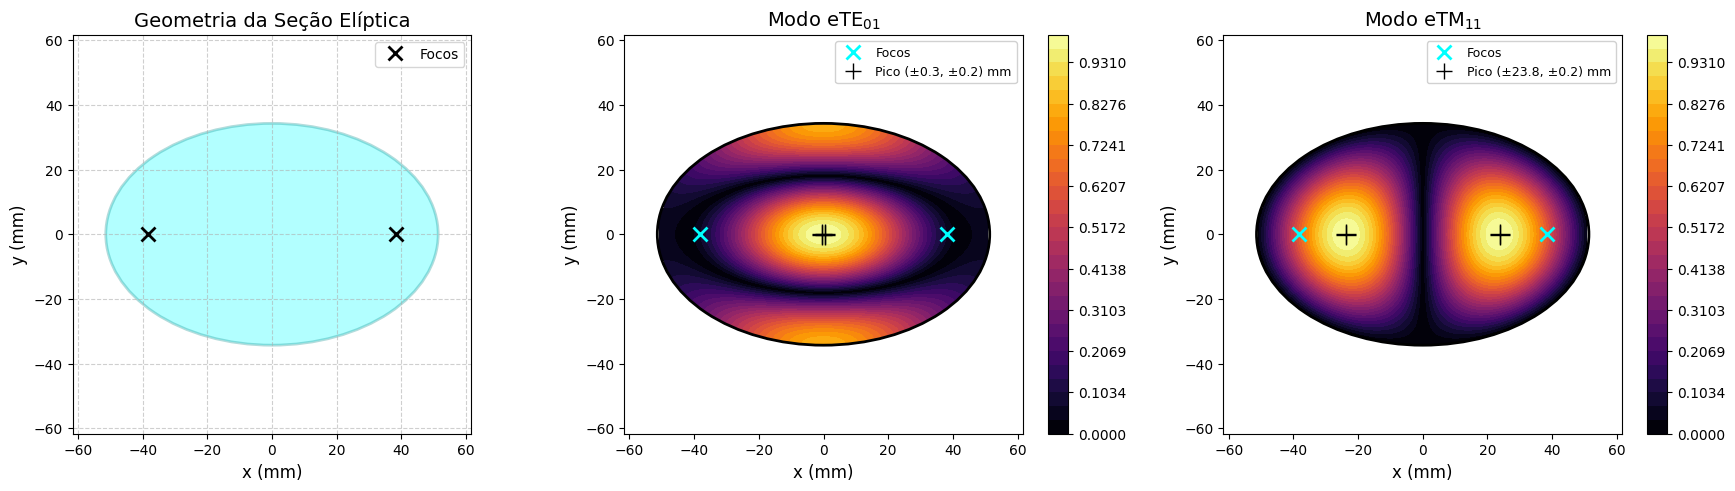

In [31]:
# ==========================================
# EXECUÇÃO DO CÓDIGO
# ==========================================
if __name__ == "__main__":
    a_cm = 5.140  # Semi-eixo maior
    b_cm = 3.430  # Semi-eixo menor
    er_val = 1.0

    # Instanciando a classe
    secao_elip = SecaoEliptica2D(a=a_cm * sc.centi, b=b_cm * sc.centi, er=er_val)

    # Plotando o painel 1x3 (Geometria, TE11, TM11)
    plotar_resumo_1x3(secao_elip, modo_te=(0, 1), modo_tm=(1, 1))

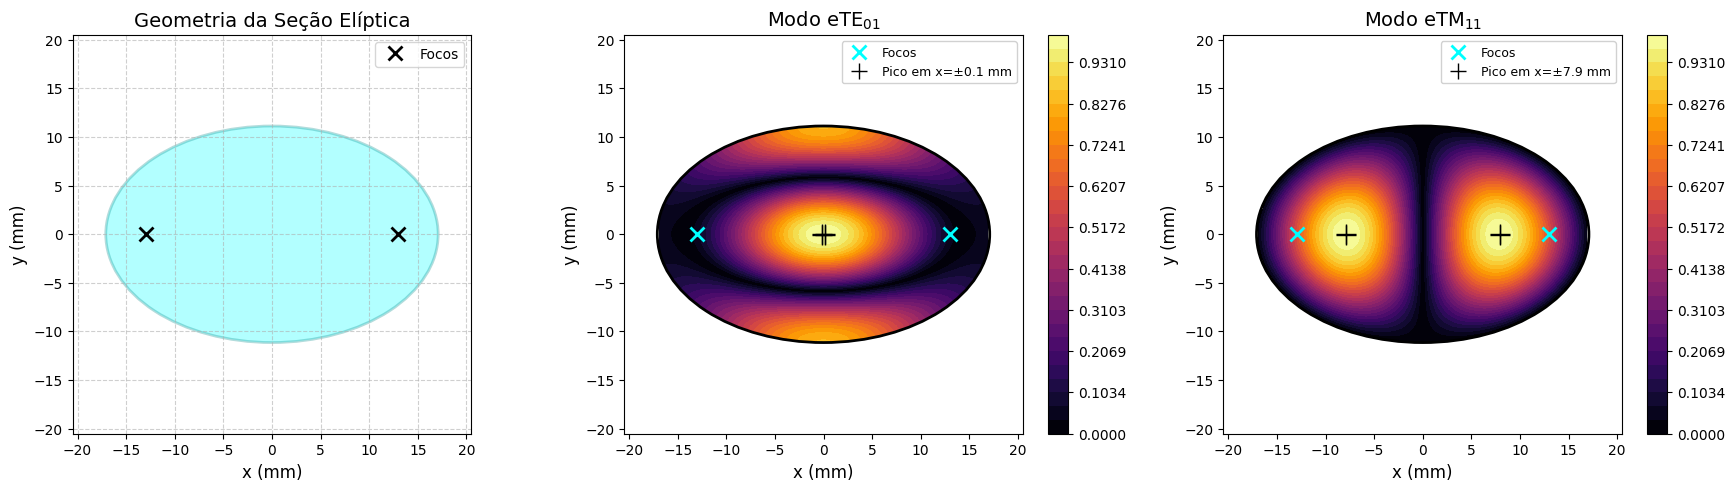

In [32]:
# ==========================================
# EXECUÇÃO DO CÓDIGO
# ==========================================
if __name__ == "__main__":
    a_cm = 1.710  # Semi-eixo maior
    b_cm = 1.114  # Semi-eixo menor
    er_val = 9.0

    # Instanciando a classe
    secao_elip = SecaoEliptica2D(a=a_cm * sc.centi, b=b_cm * sc.centi, er=er_val)

    # Plotando o painel 1x3 (Geometria, TE11, TM11)
    plotar_resumo_1x3(secao_elip, modo_te=(0, 1), modo_tm=(1, 1))

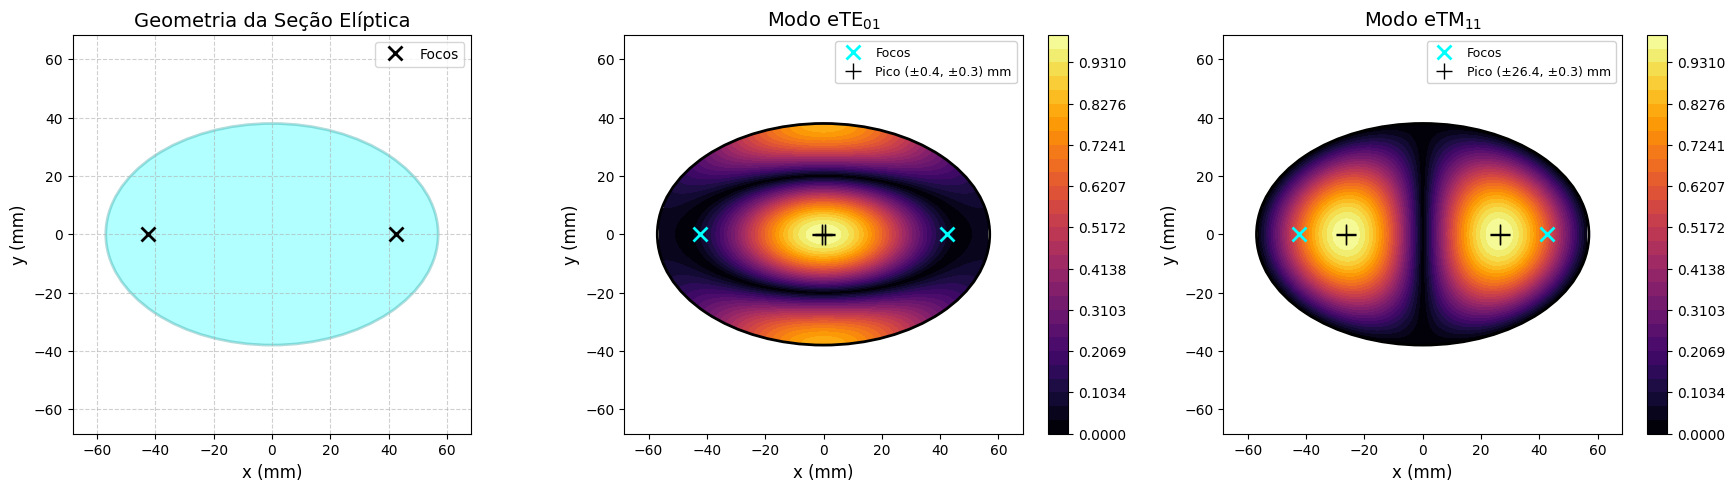

In [33]:
# ==========================================
# EXECUÇÃO DO CÓDIGO
# ==========================================
if __name__ == "__main__":
    a_cm = 5.7  # Semi-eixo maior
    b_cm = 3.8  # Semi-eixo menor
    er_val = 80.0

    # Instanciando a classe
    secao_elip = SecaoEliptica2D(a=a_cm * sc.centi, b=b_cm * sc.centi, er=er_val)

    # Plotando o painel 1x3 (Geometria, TE11, TM11)
    plotar_resumo_1x3(secao_elip, modo_te=(0, 1), modo_tm=(1, 1))